# JLT invited — end-to-end BPAM-4 over the agreed IM/DD chain

Reproduces the end-to-end (autoencoder) curve of the paper: **BER vs OSNR**, for `N_ADC` =
ideal / 8 / 6 / 5 at fixed `N_DAC = 6`.

The chain is defined **once** in `functions/scenarios.py` (`jlt_chain`) and is shared with the
experiment drivers, so the figures in `results/paper/` can always be regenerated from here.

* Chain: TX-DSP → 20 GHz rect → DAC(6) → MZM (null bias, ER 30 dB) → 10.238 km C-band →
  WSS + ASE → photodiode (25 GHz) → 10 GHz Gaussian → 2 sps → ADC → RX-DSP.
* Axis: `OSNR = Eb/N0 + 2.05 dB` (Luca, 2026-07-16: signal 1 pol, ASE 2 pol, Bref 12.5 GHz).
* Each network is measured **directly versus OSNR** (the noise model is fed the Eb/N0 that
  corresponds to each OSNR point — no BER is ever converted from another axis).

The BPAM + adaptive-equalizer reference is *not* produced here: it comes from the MATLAB
simulator (`PAM_bipolare_DD_nuovi__sorgenti/driver_baseline_jlt.m`) and is read from
`results/paper/bpam_ae_reference.txt` if present.


## 1. Setup and knobs

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
sys.path.insert(0, "functions")

%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import matplotlib.pyplot as plt

from scenarios import jlt_chain, checkpoint_name, OSNR_OFFSET_DB, TRAIN_EBN0_DB, TRAIN_STEPS
from train import train, evaluate

%matplotlib inline
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# ---------------- knobs ----------------
WIDTH      = 16          # hidden width W of both TX-DSP and RX-DSP (paper curve: 16)
DEPTH      = 1           # hidden layers D (paper curve: 1)
ADC_BITS   = [None, 8, 6, 5]   # None = ideal ADC; the paper family is 8/6/5
SEED       = 0
NUM_STEPS  = TRAIN_STEPS       # 100k
FORCE_RETRAIN = True    # True -> ignore existing checkpoints

# evaluation versus OSNR: each net is measured directly at the Eb/N0 values that correspond
# to the integer-OSNR points (no conversion after the fact).
OSNR_GRID = list(range(11, 21))                            # 11..20 dB
EBN0_FOR_OSNR = [o - OSNR_OFFSET_DB for o in OSNR_GRID]    # 8.95..17.95 dB

# symbols per point (more at high SNR to keep the BER estimate stable)
def num_symbols(ebn0_db):
    return 4_000_000 if ebn0_db <= 14.0 else 16_000_000

cfg_preview = jlt_chain(width=WIDTH, depth=DEPTH, adc_bits=6)
print(cfg_preview.summary())

device: cuda
symbol rate          : 20 GBaud
bit rate             : 40 Gb/s  (bipolar PAM-4/DD (differential sign, 2 rx sps))
sim sample rate      : 40 GHz  (2 sps, Nyquist 20 GHz)
rx sample rate       : 40 GHz  (2 sps)
photodiode bandwidth : 25 GHz  (representable: False)
modulator            : mzm  (MZM 30 GHz, 1 segments)
pulse shape          : freq-rect 20 GHz (brickwall)
equalizer            : DPD (TX) + FFE (RX), trained jointly
wavelength band      : cband  (1550 nm, beta2 -21.7 ps^2/km, L 10.238 km, beta2*L -222.2 ps^2)
noise regime         : ase
optical filter       : wss, Bo 37 GHz


## 2. Train (or load) one network per ADC resolution

One checkpoint per configuration: the file name encodes W, D, N_DAC, N_ADC, seed and steps, so
different runs cannot silently overwrite each other.

In [2]:
def load_or_train(adc_bits, force_retrain=False):
    """Returns (tx, ch, rx, cfg) for the JLT chain at the given ADC resolution."""
    cfg = jlt_chain(width=WIDTH, depth=DEPTH, adc_bits=adc_bits)
    path = checkpoint_name(cfg, WIDTH, DEPTH, adc_bits, SEED, NUM_STEPS)
    os.makedirs(os.path.dirname(path), exist_ok=True)

    torch.manual_seed(SEED)
    np.random.seed(SEED)

    if os.path.exists(path) and not force_retrain:
        from transmitter import Transmitter
        from receiver import Receiver
        from channel import OpticalChannel
        tx, ch, rx = Transmitter(cfg).to(device), OpticalChannel(cfg).to(device), Receiver(cfg).to(device)
        state = torch.load(path, map_location=device, weights_only=True)
        tx.load_state_dict(state["tx"]); rx.load_state_dict(state["rx"])
        tx.eval(); rx.eval()
        print(f"loaded {path}")
    else:
        print(f"training N_ADC={adc_bits} ({NUM_STEPS} steps, train@Eb/N0={TRAIN_EBN0_DB})")
        tx, ch, rx = train(cfg, device, num_steps=NUM_STEPS,
                           ebn0_range=(TRAIN_EBN0_DB, TRAIN_EBN0_DB))
        torch.save({"tx": tx.state_dict(), "rx": rx.state_dict()}, path)
        print(f"saved {path}")
    return tx, ch, rx, cfg


nets = {}
for adc in ADC_BITS:
    nets[adc] = load_or_train(adc, force_retrain=FORCE_RETRAIN)
    torch.cuda.empty_cache()
print("\nready:", ["ideal" if a is None else a for a in nets])

training N_ADC=None (100000 steps, train@Eb/N0=14.0)
=== training (equalizer=end-to-end) — symbol CE + per-bit BCE ===
  step    0  ebn0 14.0  ce 2.08687329  gap-spread 0.587  BER 0.5029307604
  step 12500  ebn0 14.0  ce 0.07064320  gap-spread 0.750  BER 0.0149536133
  step 25000  ebn0 14.0  ce 0.04034803  gap-spread 0.772  BER 0.0095214844
  step 37500  ebn0 14.0  ce 0.02325390  gap-spread 0.818  BER 0.0042724609
  step 50000  ebn0 14.0  ce 0.01853445  gap-spread 0.817  BER 0.0028076172
  step 62500  ebn0 14.0  ce 0.02379122  gap-spread 0.812  BER 0.0033569336
  step 75000  ebn0 14.0  ce 0.01666580  gap-spread 0.856  BER 0.0023803711
  step 87500  ebn0 14.0  ce 0.01583629  gap-spread 0.790  BER 0.0022583008
  step 99999  ebn0 14.0  ce 0.01412711  gap-spread 0.774  BER 0.0025024414
saved results/jlt_cband_bpam4_W16_D1_win11_sps2_dac6_idealADC_seed0_100k.pt
training N_ADC=8 (100000 steps, train@Eb/N0=14.0)
=== training (equalizer=end-to-end) — symbol CE + per-bit BCE ===
  step    0  eb

## 3. Measure BER versus OSNR

Every point is measured by feeding the noise model the Eb/N0 that corresponds to that OSNR, so
the curve is measured directly rather than shifted from another axis.

In [3]:
results = {"osnr": {}}

for adc, (tx, ch, rx, cfg) in nets.items():
    tag = "ideal" if adc is None else str(adc)
    results["osnr"][tag] = [evaluate(tx, ch, rx, cfg, [e], num_symbols(e), device)[0]
                            for e in EBN0_FOR_OSNR]
    torch.cuda.empty_cache()
    print(f"N_ADC={tag}  done")

# summary table on the OSNR grid
print("\nOSNR [dB] " + " ".join(f"{o:>9d}" for o in OSNR_GRID))
for tag, bers in results["osnr"].items():
    print(f"N_ADC={tag:>5s} " + " ".join(f"{b:9.2e}" for b in bers))

Eb/N0   8.9 dB   BER 5.324e-02   (shift 0)
Eb/N0   9.9 dB   BER 3.384e-02   (shift 0)
Eb/N0  10.9 dB   BER 1.969e-02   (shift 0)
Eb/N0  11.9 dB   BER 1.055e-02   (shift 0)
Eb/N0  12.9 dB   BER 5.025e-03   (shift 0)
Eb/N0  13.9 dB   BER 2.166e-03   (shift 0)
Eb/N0  14.9 dB   BER 8.296e-04   (shift 0)
Eb/N0  15.9 dB   BER 2.828e-04   (shift 0)
Eb/N0  16.9 dB   BER 8.447e-05   (shift 0)
Eb/N0  17.9 dB   BER 2.319e-05   (shift 0)
N_ADC=ideal  done
Eb/N0   8.9 dB   BER 5.335e-02   (shift 0)
Eb/N0   9.9 dB   BER 3.416e-02   (shift 0)
Eb/N0  10.9 dB   BER 1.988e-02   (shift 0)
Eb/N0  11.9 dB   BER 1.064e-02   (shift 0)
Eb/N0  12.9 dB   BER 5.258e-03   (shift 0)
Eb/N0  13.9 dB   BER 2.255e-03   (shift 0)
Eb/N0  14.9 dB   BER 8.715e-04   (shift 0)
Eb/N0  15.9 dB   BER 3.068e-04   (shift 0)
Eb/N0  16.9 dB   BER 9.575e-05   (shift 0)
Eb/N0  17.9 dB   BER 2.556e-05   (shift 0)
N_ADC=8  done
Eb/N0   8.9 dB   BER 5.409e-02   (shift 0)
Eb/N0   9.9 dB   BER 3.414e-02   (shift 0)
Eb/N0  10.9 dB   BER 2

## 4. Save the column files (format used by the co-authors)

In [4]:
OUT = os.path.join("results", "paper")
os.makedirs(OUT, exist_ok=True)

HEADER = (
    "# End-to-end BPAM-4 (this work), W={W} D={D} seed{S}, {N} steps, C-band 10.238 km,\n"
    "# MZM ER 30 dB, TX 20 GHz rect, RX 10 GHz Gaussian, N_DAC=6.\n"
    "# Native OSNR axis (each network measured directly at these points).\n"
    "# OSNR = Eb/N0 + {off} dB (signal 1 pol, ASE 2 pol, Bref 12.5 GHz).\n"
    "# col1=OSNR[dB]  col2=ideal ADC  col3=N_ADC 8  col4=N_ADC 6  col5=N_ADC 5\n")

with open(os.path.join(OUT, "notebook_e2e_osnr.txt"), "w") as f:
    f.write(HEADER.format(W=WIDTH, D=DEPTH, S=SEED, N=NUM_STEPS, off=OSNR_OFFSET_DB))
    for i, o in enumerate(OSNR_GRID):
        row = "  ".join(f"{results['osnr'][t][i]:.4e}" for t in ("ideal", "8", "6", "5"))
        f.write(f"  {o:6.2f}  {row}\n")
print("written", os.path.join(OUT, "notebook_e2e_osnr.txt"))

written results\paper\notebook_e2e_osnr.txt


## 5. Figures

Solid: end-to-end (this work). Dashed (if available): BPAM + adaptive equalizer from the MATLAB
simulator, same scenario and same `N_ADC`.

baseline loaded for N_ADC: [5, 6, 8]


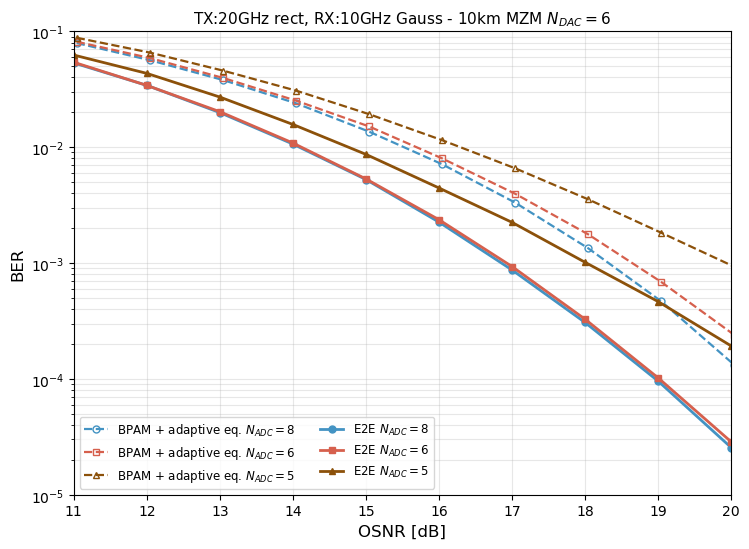

In [5]:
# optional reference produced by driver_baseline_jlt.m ('prod' mode)
REF = os.path.join(OUT, "bpam_ae_reference.txt")
baseline = {}
if os.path.exists(REF):
    for line in open(REF):
        if line.startswith("#") or not line.strip():
            continue
        p = line.split()
        nadc, ebn0, osnr, ber = int(p[0]), float(p[2]), float(p[3]), float(p[4])
        baseline.setdefault(nadc, {"ebn0": [], "osnr": [], "ber": []})
        baseline[nadc]["ebn0"].append(ebn0)
        baseline[nadc]["osnr"].append(osnr)
        baseline[nadc]["ber"].append(ber)
    print("baseline loaded for N_ADC:", sorted(baseline))
else:
    print("no baseline file - plotting the end-to-end curves only")

STYLE = {"8": ("-o", "#4393c3"), "6": ("-s", "#d6604d"), "5": ("-^", "#8c510a"),
         "ideal": ("-D", "k")}

def figure(axis, grid, xlabel, key, fname, show_ideal=False):
    fig, ax = plt.subplots(figsize=(7.6, 5.6))
    for nb in (8, 6, 5):
        if nb not in baseline:
            continue
        mk, c = STYLE[str(nb)]
        pts = [(x, y) for x, y in zip(baseline[nb][key], baseline[nb]["ber"]) if y > 0]
        ax.semilogy([p[0] for p in pts], [p[1] for p in pts], "--" + mk[1:], color=c,
                    lw=1.6, ms=5, mfc="none", label=f"BPAM + adaptive eq. $N_{{ADC}}={nb}$")
    tags = (["ideal"] if show_ideal else []) + ["8", "6", "5"]
    for tag in tags:
        if tag not in results[axis]:
            continue
        mk, c = STYLE[tag]
        lab = "E2E ideal ADC" if tag == "ideal" else f"E2E $N_{{ADC}}={tag}$"
        ax.semilogy(grid, np.maximum(results[axis][tag], 1e-7), mk, color=c, lw=2, ms=5, label=lab)
    ax.set_xlim(min(grid), max(grid)); ax.set_ylim(1e-5, 1e-1); ax.set_xticks(grid)
    ax.set_xlabel(xlabel, fontsize=12); ax.set_ylabel("BER", fontsize=12)
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8.5, loc="lower left", ncol=2)
    ax.set_title("TX:20GHz rect, RX:10GHz Gauss - 10km MZM $N_{DAC}=6$", fontsize=11)
    fig.tight_layout()
    fig.savefig(os.path.join(OUT, fname + ".png"), bbox_inches="tight", dpi=150)
    fig.savefig(os.path.join(OUT, fname + ".pdf"), bbox_inches="tight")
    plt.show()

figure("osnr", OSNR_GRID, "OSNR [dB]", "osnr", "notebook_e2e_osnr")


## 5b. Eye diagram at the matched-filter output

As in `pam4_analysis`: noiseless waveform of each trained transmitter, matched-filter output,
sampled at the phase that best separates the levels. With the discovered signaling the eye can
look closed — the decision lives in the RX context window, the eye documents the waveform.

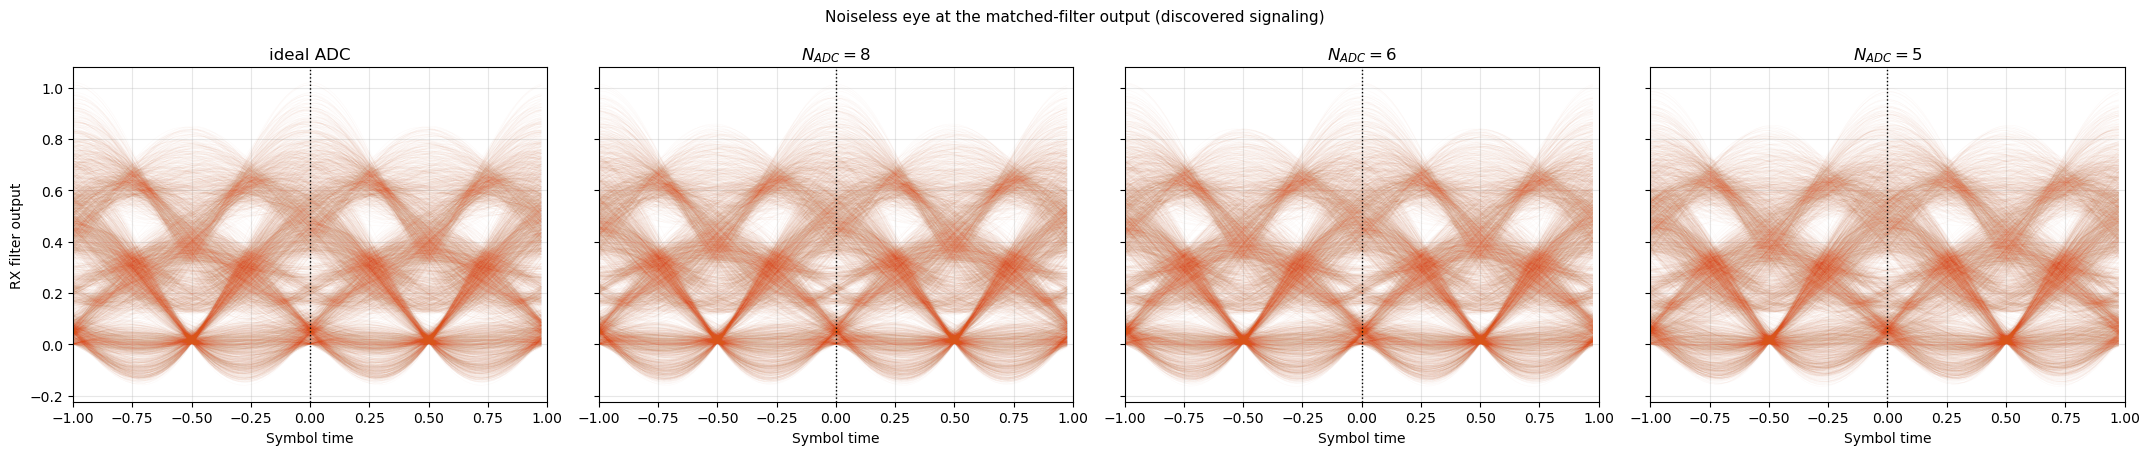

In [6]:
import torch.nn.functional as F
from scipy.signal import resample_poly
from train import random_bits
from transmitter import bits_to_symbols
from utils import decision_phase_by_separation

def draw_eye(ax, signal, samples_per_symbol, phase, title, fine_sps=40, skip=100, num_symbols=4000):
    fine = resample_poly(signal[:(skip + num_symbols + 8) * samples_per_symbol],
                         fine_sps, samples_per_symbol)
    offset = int(round(phase * fine_sps / samples_per_symbol))
    centers = (skip + np.arange(num_symbols)) * fine_sps + offset
    keep = (centers - fine_sps >= 0) & (centers + fine_sps < len(fine))
    centers = centers[keep]
    window = np.arange(-fine_sps, fine_sps)[:, None] + centers[None, :]
    ax.plot(np.arange(-fine_sps, fine_sps) / fine_sps, fine[window],
            color=(0.85, 0.33, 0.10, 0.03), linewidth=0.4)
    ax.axvline(0, color="k", linestyle=":", linewidth=1)
    ax.set_xlim(-1, 1)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Symbol time")
    ax.set_title(title)

fig, axes = plt.subplots(1, len(nets), figsize=(5.4 * len(nets), 4.6), sharey=True)
axes = np.atleast_1d(axes)
for ax, (adc, item) in zip(axes, nets.items()):
    tx, ch, rx, cfg = item
    sps = cfg.samples_per_symbol_sim
    mf_pad = rx.matched.shape[-1] // 2
    torch.manual_seed(7)
    with torch.no_grad():
        bits = random_bits(cfg.bits_per_symbol, 6000, device)
        symbols = bits_to_symbols(bits, cfg.bits_per_symbol).cpu().numpy()
        fr, fi = ch.complex_envelope(tx(bits), None)          # noiseless optical field
        mr = F.conv1d(fr.view(1, 1, -1), rx.matched, padding=mf_pad).squeeze()
        mi = F.conv1d(fi.view(1, 1, -1), rx.matched, padding=mf_pad).squeeze()
        matched = (mr ** 2 + mi ** 2).cpu().numpy()
    phase, _ = decision_phase_by_separation(matched, sps, symbols, skip=100)
    title = "ideal ADC" if adc is None else f"$N_{{ADC}}={adc}$"
    draw_eye(ax, matched, sps, phase, title)
axes[0].set_ylabel("RX filter output")
fig.suptitle("Noiseless eye at the matched-filter output (discovered signaling)", fontsize=11)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "simple_eyes.png"), dpi=150, bbox_inches="tight")
plt.show()

## 6. Horizontal gain vs the reference, at equal ADC resolution

In [7]:
def crossing(x, y, target):
    """Interpolate (log-linearly) the abscissa where the curve crosses a BER target."""
    x = np.asarray(x, float)
    ly = np.log10(np.maximum(np.asarray(y, float), 1e-12))
    lt = np.log10(target)
    for i in range(len(x) - 1):
        if (ly[i] - lt) * (ly[i + 1] - lt) <= 0:
            return x[i] + (x[i + 1] - x[i]) * (lt - ly[i]) / (ly[i + 1] - ly[i])
    return np.nan

if baseline:
    for target in (1e-2, 1e-3):
        print(f"\nBER = {target:.0e}   (OSNR axis)")
        for nb in (8, 6, 5):
            if nb not in baseline:
                continue
            bx = [x for x, y in zip(baseline[nb]["osnr"], baseline[nb]["ber"]) if y > 0]
            by = [y for y in baseline[nb]["ber"] if y > 0]
            gb = crossing(bx, by, target)
            ge = crossing(OSNR_GRID, results["osnr"][str(nb)], target)
            print(f"  N_ADC={nb}:  baseline @ {gb:5.2f} dB   E2E @ {ge:5.2f} dB"
                  f"   ->  gain {gb - ge:+.2f} dB")
else:
    print("run driver_baseline_jlt('prod') in MATLAB to enable this comparison")


BER = 1e-02   (OSNR axis)
  N_ADC=8:  baseline @ 15.52 dB   E2E @ 14.09 dB   ->  gain +1.43 dB
  N_ADC=6:  baseline @ 15.69 dB   E2E @ 14.12 dB   ->  gain +1.58 dB
  N_ADC=5:  baseline @ 16.29 dB   E2E @ 14.76 dB   ->  gain +1.53 dB

BER = 1e-03   (OSNR axis)
  N_ADC=8:  baseline @ 18.32 dB   E2E @ 16.86 dB   ->  gain +1.47 dB
  N_ADC=6:  baseline @ 18.65 dB   E2E @ 16.93 dB   ->  gain +1.72 dB
  N_ADC=5:  baseline @ 19.93 dB   E2E @ 18.02 dB   ->  gain +1.92 dB
